# STEP 6. 성향점수매칭 (PSM)

> **H2**: 골목상권의 순감소 위험이 높은 업종의 경우, **점포 규모와 유동인구를 맞추면** 타 업종과 순감소 격차가 줄어들 것이다.

## 매칭 전 SMD 가 전부 "심각한 불균형"인데 진행해도 되나

**그게 매칭을 하는 이유입니다.** 매칭 전 SMD 는 통과해야 할 관문이 아니라 **문제의 크기를 재는 눈금**입니다.

- SMD 가 작았다면 → 두 집단이 이미 비슷하므로 단순 비교로 충분하고 PSM 이 불필요
- SMD 가 크다 → 두 집단이 원래 다른 조건에 분포해 있다는 증거. 단순 비교는 "업종 때문"과 "규모 때문"을 구분하지 못함

STEP 5 의 규모 구간 진단이 이를 뒷받침합니다 — 단순 격차는 **+2.4%p** 인데 다섯 규모 구간 **전부** 에서 한식이 더 낮았습니다(평균 −5.3%p). 심슨의 역설입니다.

**관문은 매칭 _후_ SMD 입니다.** 6-4 에서 모든 공변량 |SMD| < 0.1 을 통과하지 못하면 6-5 의 ATT 를 해석하지 않습니다.

## 절차

| | 하는 일 | 확인 기준 |
|---|---|---|
| 6-1 | 성향점수 추정 (로지스틱) | 계수 부호가 STEP 5 SMD 와 일치 |
| 6-2 | 공통지지영역 트리밍 | 버려지는 관측치 비율 |
| 6-3 | 1:1 최근접 매칭 (분기 고정 + 캘리퍼, 비복원) | 매칭률 |
| 6-4 | **매칭 후 균형 검증** ★ | 모든 공변량 \|SMD\| < 0.1 |
| 6-5 | ATT + McNemar + 클러스터 부트스트랩 | 격차가 어떻게 변했나 |
| 6-6 | 매칭 실패 처리군 진단 | 버린 관측치가 결과를 만든 건 아닌가 |
| 6-7 | 민감도 (캘리퍼·복원·시드·자치구·매출) | 설정을 바꿔도 결론이 유지되나 |


In [1]:
import sys, os
from pathlib import Path

# 노트북이 어디서 열리든 프로젝트 루트를 찾아 sys.path에 추가
ROOT = Path.cwd()
while not (ROOT / "config.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import numpy as np
import pandas as pd
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)
print("프로젝트 루트:", ROOT)

프로젝트 루트: c:\Users\spide\ai-data-bootcamp\project\h2_nb


In [2]:
import matplotlib.pyplot as plt
from scipy.stats import binomtest
from sklearn.linear_model import LogisticRegression
from config import PROC, FIG, TARGET_TYPE, COVARIATES, set_korean_font
set_korean_font()
OUT = FIG.parent

SEED    = 42
CALIPER = 0.2                  # logit(PS) 표준편차 배수 — Austin(2011) 권장
EXACT   = "기준_년분기_코드"    # 분기는 반드시 같은 값끼리만 매칭
B_BOOT  = 500

def smd(a, b):
    """표준화 평균차. |SMD| < 0.1 이면 균형"""
    return (a.mean() - b.mean()) / np.sqrt((a.var() + b.var()) / 2)

gm = pd.read_pickle(PROC / "05_golmok.pkl").reset_index(drop=True)
TREAT = gm.loc[gm["처리"] == 1, "서비스_업종_코드_명"].iloc[0]

gap_before = gm.loc[gm["처리"]==1, "y"].mean() - gm.loc[gm["처리"]==0, "y"].mean()
print(f"입력 {gm.shape}")
print(f"처리군 {TREAT} n={int(gm['처리'].sum()):,} / 대조군 n={int((1-gm['처리']).sum()):,}")
print(f"매칭 전 단순 격차 {gap_before:+.1%}p")

입력 (34647, 38)
처리군 한식음식점 n=9,957 / 대조군 n=24,690
매칭 전 단순 격차 +2.4%p


## 6-1. 성향점수 추정

성향점수 = **공변량만 보고 예측한 "이 칸이 처리군일 확률"**. 결과변수 `y` 는 절대 넣지 않습니다 — 넣으면 결과를 보고 짝을 고르는 셈이 되어 편향이 생깁니다.

4개 공변량에 **분기 더미**를 추가합니다. 2023Q1 과 2025Q4 는 경기 상황이 다르므로, 같은 규모라도 다른 분기의 상권과 비교하면 시점 효과가 섞입니다.

In [3]:
def fit_ps(frame, covs=COVARIATES):
    X = pd.concat([
        frame[covs],
        pd.get_dummies(frame["기준_년분기_코드"], prefix="q", drop_first=True).astype(float),
    ], axis=1)
    m = LogisticRegression(max_iter=3000, C=1e6).fit(X, frame["처리"])
    ps = m.predict_proba(X)[:, 1]
    return ps, pd.Series(m.coef_[0][:len(covs)], index=covs)

gm["ps"], coef = fit_ps(gm)
gm["logit_ps"] = np.log(gm["ps"] / (1 - gm["ps"]))

print("성향점수 모형 계수 (공변량만 표시)")
display(coef.sort_values().round(3).to_frame("계수"))
print("※ 부호가 STEP 5 의 SMD 부호와 일치해야 정상입니다.")
print(f"   log_점포수가 크게 (+) → 점포가 많은 칸일수록 {TREAT}일 확률이 높다는 뜻")

성향점수 모형 계수 (공변량만 표시)


,계수
log_면적,-0.697
log_집객시설,-0.609
log_유동인구,-0.553
log_점포수,2.364


※ 부호가 STEP 5 의 SMD 부호와 일치해야 정상입니다.
   log_점포수가 크게 (+) → 점포가 많은 칸일수록 한식음식점일 확률이 높다는 뜻


## 6-2. 공통지지영역 트리밍

PS 가 처리군·대조군 범위의 교집합 밖에 있는 관측치는 **비교 대상 자체가 없으므로** 제거합니다.

In [4]:
lo = max(gm.loc[gm["처리"]==1, "ps"].min(), gm.loc[gm["처리"]==0, "ps"].min())
hi = min(gm.loc[gm["처리"]==1, "ps"].max(), gm.loc[gm["처리"]==0, "ps"].max())
support = (gm["ps"] >= lo) & (gm["ps"] <= hi)

dd = gm[support].copy()
print(f"공통지지 구간 PS [{lo:.3f}, {hi:.3f}]")
print(f"유지 {support.sum():,} / {len(gm):,} ({support.mean():.1%})   제거 {(~support).sum():,}행")

공통지지 구간 PS [0.012, 0.999]
유지 33,935 / 34,647 (97.9%)   제거 712행


## 6-3. 1:1 최근접 매칭

- **거리** — logit(PS) 차이. PS 원척도는 0·1 근처에서 눌려 있어 logit 이 표준입니다
- **캘리퍼** — logit(PS) 표준편차 × 0.2. 이보다 멀면 짝을 짓지 않고 버립니다 (억지 매칭 방지)
- **분기 고정** — 같은 분기 안에서만 짝을 찾습니다
- **비복원** — 대조군 한 칸은 한 번만 쓰입니다
- 탐욕적(greedy) 매칭이라 처리 순서에 따라 결과가 미세하게 달라집니다 → 시드 고정 후 6-7 에서 변경 확인

In [5]:
def nn_match(df, caliper_mult=CALIPER, replace=False, seed=SEED, exact=EXACT):
    """logit(PS) 기준 1:1 최근접 매칭. (처리 index, 대조 index) 쌍 반환"""
    cal = caliper_mult * df["logit_ps"].std()
    pairs = []
    if exact is None:
        groups = [(None, df)]
    elif isinstance(exact, (list, tuple)):
        groups = df.groupby(list(exact))
    else:
        groups = df.groupby(exact)

    for _, sub in groups:
        tr = sub[sub["처리"] == 1].sample(frac=1, random_state=seed)
        ct = sub[sub["처리"] == 0]
        if len(ct) == 0:
            continue
        cl, cidx = ct["logit_ps"].to_numpy(), ct.index.to_numpy()
        order = np.argsort(cl); cl, cidx = cl[order], cidx[order]
        used = np.zeros(len(cl), bool)

        for ti, tv in zip(tr.index, tr["logit_ps"].to_numpy()):
            pos = np.searchsorted(cl, tv)
            l, r, best = pos - 1, pos, -1
            while l >= 0 or r < len(cl):          # 삽입 위치에서 좌우로 확장
                dl = tv - cl[l] if l >= 0      else np.inf
                dr = cl[r] - tv if r < len(cl) else np.inf
                if min(dl, dr) > cal:             # 캘리퍼 밖 → 포기
                    break
                if dl <= dr:
                    if replace or not used[l]: best = l; break
                    l -= 1
                else:
                    if replace or not used[r]: best = r; break
                    r += 1
            if best >= 0:
                if not replace:
                    used[best] = True
                pairs.append((ti, cidx[best]))

    return pd.DataFrame(pairs, columns=["t_idx", "c_idx"]), cal


mp, cal = nn_match(dd)
t_idx, c_idx = mp["t_idx"].to_numpy(), mp["c_idx"].to_numpy()
n_treat = int(dd["처리"].sum())

print(f"캘리퍼 = {cal:.3f}  (logit PS 표준편차 {dd['logit_ps'].std():.3f} × {CALIPER})")
print(f"매칭쌍 {len(mp):,}쌍   처리군 매칭률 {len(mp)/n_treat:.1%}  (실패 {n_treat-len(mp):,}칸)")

캘리퍼 = 0.332  (logit PS 표준편차 1.660 × 0.2)
매칭쌍 7,043쌍   처리군 매칭률 70.7%  (실패 2,912칸)


## 6-4. 매칭 후 균형 검증 ★

**여기가 관문입니다.** 모든 공변량 |SMD| < 0.1 을 만족해야 "조건을 맞췄다"고 말할 수 있고, 그래야 6-5 의 격차를 업종 효과로 해석할 수 있습니다.

In [6]:
rows = []
for c in COVARIATES + ["logit_ps"]:
    s_bef = smd(gm.loc[gm["처리"]==1, c], gm.loc[gm["처리"]==0, c])
    s_aft = smd(gm.loc[t_idx, c],        gm.loc[c_idx, c])
    rows.append({"공변량": c,
                 "매칭전_SMD": s_bef, "매칭후_SMD": s_aft,
                 "처리군평균": gm.loc[t_idx, c].mean(), "대조군평균": gm.loc[c_idx, c].mean(),
                 "감소율": 1 - abs(s_aft)/abs(s_bef),
                 "판정": "균형" if abs(s_aft) < 0.1 else ("불균형" if abs(s_aft) < 0.25 else "심각한 불균형")})

bal = pd.DataFrame(rows)
display(bal.round(3))
bal.to_csv(OUT / "h2_balance_after.csv", index=False, encoding="utf-8-sig")

ok = (bal["매칭후_SMD"].abs() < 0.1).all()
print("✅ 모든 공변량 균형 달성 → ATT 해석 가능" if ok
      else "❌ 균형 미달 — 캘리퍼 축소 / 공변량 재설정 필요. 아래 ATT 를 해석하지 마세요.")

,공변량,매칭전_SMD,매칭후_SMD,처리군평균,대조군평균,감소율,판정
0,log_점포수,0.999,0.037,2.603,2.580,0.963,균형
1,log_유동인구,-0.447,0.022,13.417,13.396,0.951,균형
2,log_면적,-0.473,0.031,11.359,11.338,0.935,균형
3,log_집객시설,-0.461,0.030,2.508,2.486,0.934,균형
4,logit_ps,1.553,0.014,-0.286,-0.301,0.991,균형


✅ 모든 공변량 균형 달성 → ATT 해석 가능


## 6-5. ATT 추정

**ATT** (Average Treatment effect on the Treated) = 조건이 같은 짝끼리 비교한 순감소율 차이.

- 짝 데이터이므로 McNemar 검정(불일치쌍 이항검정)을 씁니다
- 같은 상권이 최대 12분기 반복 관측되므로 신뢰구간은 **상권 단위 클러스터 부트스트랩**으로 계산합니다

In [7]:
y1 = gm.loc[t_idx, "y"].to_numpy()
y0 = gm.loc[c_idx, "y"].to_numpy()
att = (y1 - y0).mean()

print(f"매칭 전  처리 {gm.loc[gm['처리']==1,'y'].mean():.1%} vs 대조 {gm.loc[gm['처리']==0,'y'].mean():.1%}"
      f"   격차 {gap_before:+.1%}p")
print(f"매칭 후  처리 {y1.mean():.1%} vs 대조 {y0.mean():.1%}   ATT  {att:+.1%}p\n")

b = int(((y1 == 1) & (y0 == 0)).sum())   # 처리만 순감소
c = int(((y1 == 0) & (y0 == 1)).sum())   # 대조만 순감소
bt = binomtest(b, b + c, 0.5)
print(f"McNemar  불일치쌍 b(처리만)={b:,}  c(대조만)={c:,}   p = {bt.pvalue:.3g}")

clusters = gm.loc[t_idx, "상권_코드"].to_numpy()
uniq = np.unique(clusters)
pos = {u: np.where(clusters == u)[0] for u in uniq}
rng = np.random.default_rng(SEED)
boot = [(lambda s: (y1[s]-y0[s]).mean())(
            np.concatenate([pos[u] for u in rng.choice(uniq, len(uniq), replace=True)]))
        for _ in range(B_BOOT)]
ci = np.percentile(boot, [2.5, 97.5])
print(f"클러스터 부트스트랩 95% CI  [{ci[0]:+.1%}p, {ci[1]:+.1%}p]  (상권 {len(uniq)}개, {B_BOOT}회)")

pd.DataFrame([{"매칭전_격차": gap_before, "ATT": att, "CI_low": ci[0], "CI_high": ci[1],
               "McNemar_p": bt.pvalue, "쌍수": len(mp), "처리군매칭률": len(mp)/n_treat}]
             ).to_csv(OUT / "h2_att.csv", index=False, encoding="utf-8-sig")

매칭 전  처리 25.3% vs 대조 22.9%   격차 +2.4%p
매칭 후  처리 23.1% vs 대조 28.8%   ATT  -5.8%p

McNemar  불일치쌍 b(처리만)=1,140  c(대조만)=1,546   p = 4.91e-15
클러스터 부트스트랩 95% CI  [-7.2%p, -4.2%p]  (상권 853개, 500회)


## 6-6. 매칭 실패 처리군 진단

STEP 5 의 경고 — **"격차가 줄었다"가 사실은 "격차를 만들던 관측치를 버렸다"일 수 있습니다.**

짝을 못 찾은 처리군이 어떤 칸인지, 그들의 순감소율이 매칭된 처리군과 다른지 확인합니다. 다르다면 ATT 는 **매칭된 처리군에 한정된 결과**로 범위를 좁혀 보고해야 합니다.

In [8]:
tr_all = dd[dd["처리"] == 1].copy()
tr_all["매칭됨"] = tr_all.index.isin(set(t_idx))

prof = (tr_all.groupby("매칭됨")
        .agg(칸수=("y","size"), 순감소율=("y","mean"), 평균PS=("ps","mean"),
             **{c: (c, "mean") for c in COVARIATES}))
display(prof.round(3))
print("※ 매칭 실패 칸의 순감소율이 매칭된 칸보다 뚜렷이 높다면,")
print("   ATT 는 '비교 가능한 규모 구간에 한정된' 효과로 해석 범위를 제한해야 합니다.")

,칸수,순감소율,평균PS,log_점포수,log_유동인구,log_면적,log_집객시설
매칭됨,,,,,,,
False,2912,0.306,0.747,3.242,13.399,11.312,2.534
True,7043,0.231,0.439,2.603,13.417,11.359,2.508


※ 매칭 실패 칸의 순감소율이 매칭된 칸보다 뚜렷이 높다면,
   ATT 는 '비교 가능한 규모 구간에 한정된' 효과로 해석 범위를 제한해야 합니다.


## 6-7. 민감도 분석

매칭 설계에는 임의 선택이 여럿 들어갑니다(캘리퍼 폭, 복원 여부, 층화 축, 처리 순서 시드). 이 선택을 바꿔도 결론이 유지되는지 확인합니다. **부호가 뒤집히거나 크기가 배로 변하면 결론을 신뢰할 수 없습니다.**

두 가지를 추가로 넣습니다.

- **자치구 고정** — 분기에 더해 자치구까지 맞춥니다. 임대료·상권 성격 등 관측 안 된 지역 요인을 흡수하지만 매칭률이 떨어집니다
- **매출 포함** — 매출이 관측된 부분표본에서 매출을 공변량에 추가합니다. 매출은 업종의 *결과*이기도 하므로 과잉통제 위험이 있어 주 분석이 아니라 참고용입니다

In [9]:
def run(label, frame=None, **kw):
    f = dd if frame is None else frame
    p, _ = nn_match(f, **kw)
    if len(p) == 0:
        return {"설정": label, "쌍수": 0, "ATT": np.nan, "최대SMD": np.nan}
    a = (gm.loc[p["t_idx"], "y"].to_numpy() - gm.loc[p["c_idx"], "y"].to_numpy()).mean()
    worst = max(abs(smd(gm.loc[p["t_idx"], c], gm.loc[p["c_idx"], c])) for c in COVARIATES)
    return {"설정": label, "쌍수": len(p), "ATT": a, "최대SMD": worst}

rows = [
    run("기준 (캘리퍼 0.2sd, 비복원, 분기고정)"),
    run("캘리퍼 0.1sd", caliper_mult=0.1),
    run("캘리퍼 0.5sd", caliper_mult=0.5),
    run("복원추출",      replace=True),
    run("분기 미고정",    exact=None),
    run("분기+자치구 고정", exact=["기준_년분기_코드", "자치구"]),
    run("시드 1",    seed=1),
    run("시드 7",    seed=7),
    run("시드 2024", seed=2024),
]
sens = pd.DataFrame(rows)
display(sens.round(4))

,설정,쌍수,ATT,최대SMD
0,"기준 (캘리퍼 0.2sd, 비복원, 분기고정)",7043,-0.0576,0.0368
1,캘리퍼 0.1sd,6971,-0.0598,0.0314
2,캘리퍼 0.5sd,7460,-0.0534,0.0849
3,복원추출,9940,-0.0468,0.1451
4,분기 미고정,7059,-0.0557,0.0501
5,분기+자치구 고정,6118,-0.0582,0.0506
6,시드 1,7054,-0.0591,0.0456
7,시드 7,7053,-0.0552,0.0504
8,시드 2024,7052,-0.0533,0.0484


In [10]:
# 매출 포함 (관측 부분표본) — 별도 성향점수 재적합이 필요해 따로 처리
sub = gm[gm["매출_관측"]].copy()
sub["log_매출"] = np.log1p(sub["당월_매출_금액"])
COV_S = COVARIATES + ["log_매출"]
sub["ps"], _ = fit_ps(sub, COV_S)
sub["logit_ps"] = np.log(sub["ps"] / (1 - sub["ps"]))
lo2 = max(sub.loc[sub["처리"]==1,"ps"].min(), sub.loc[sub["처리"]==0,"ps"].min())
hi2 = min(sub.loc[sub["처리"]==1,"ps"].max(), sub.loc[sub["처리"]==0,"ps"].max())
sub = sub[(sub["ps"]>=lo2) & (sub["ps"]<=hi2)]

p2, _ = nn_match(sub)
att2 = (gm.loc[p2["t_idx"], "y"].to_numpy() - gm.loc[p2["c_idx"], "y"].to_numpy()).mean()
worst2 = max(abs(smd(sub.loc[p2["t_idx"], c], sub.loc[p2["c_idx"], c])) for c in COV_S)
sens = pd.concat([sens, pd.DataFrame([{
    "설정": f"매출 포함 (관측 표본 {len(sub)/len(gm):.0%})",
    "쌍수": len(p2), "ATT": att2, "최대SMD": worst2}])], ignore_index=True)

display(sens.round(4))
lo_, hi_ = sens["ATT"].min(), sens["ATT"].max()
print(f"ATT 범위 [{lo_:+.1%}p, {hi_:+.1%}p]  → "
      f"{'모든 설정에서 부호 일관' if lo_*hi_ > 0 else '부호가 뒤집힘 — 결론 보류'}")

,설정,쌍수,ATT,최대SMD
0,"기준 (캘리퍼 0.2sd, 비복원, 분기고정)",7043,-0.0576,0.0368
1,캘리퍼 0.1sd,6971,-0.0598,0.0314
2,캘리퍼 0.5sd,7460,-0.0534,0.0849
3,복원추출,9940,-0.0468,0.1451
4,분기 미고정,7059,-0.0557,0.0501
5,분기+자치구 고정,6118,-0.0582,0.0506
6,시드 1,7054,-0.0591,0.0456
7,시드 7,7053,-0.0552,0.0504
8,시드 2024,7052,-0.0533,0.0484
9,매출 포함 (관측 표본 90%),5312,-0.0446,0.0421


ATT 범위 [-6.0%p, -4.5%p]  → 모든 설정에서 부호 일관


## 6-8. 시각화

C:\Users\spide\AppData\Local\Temp\ipykernel_12116\1518973619.py:37: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\spide\AppData\Local\Temp\ipykernel_12116\1518973619.py:38: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  plt.savefig(FIG / "step6_psm.png", dpi=130)
c:\Users\spide\anaconda3\envs\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


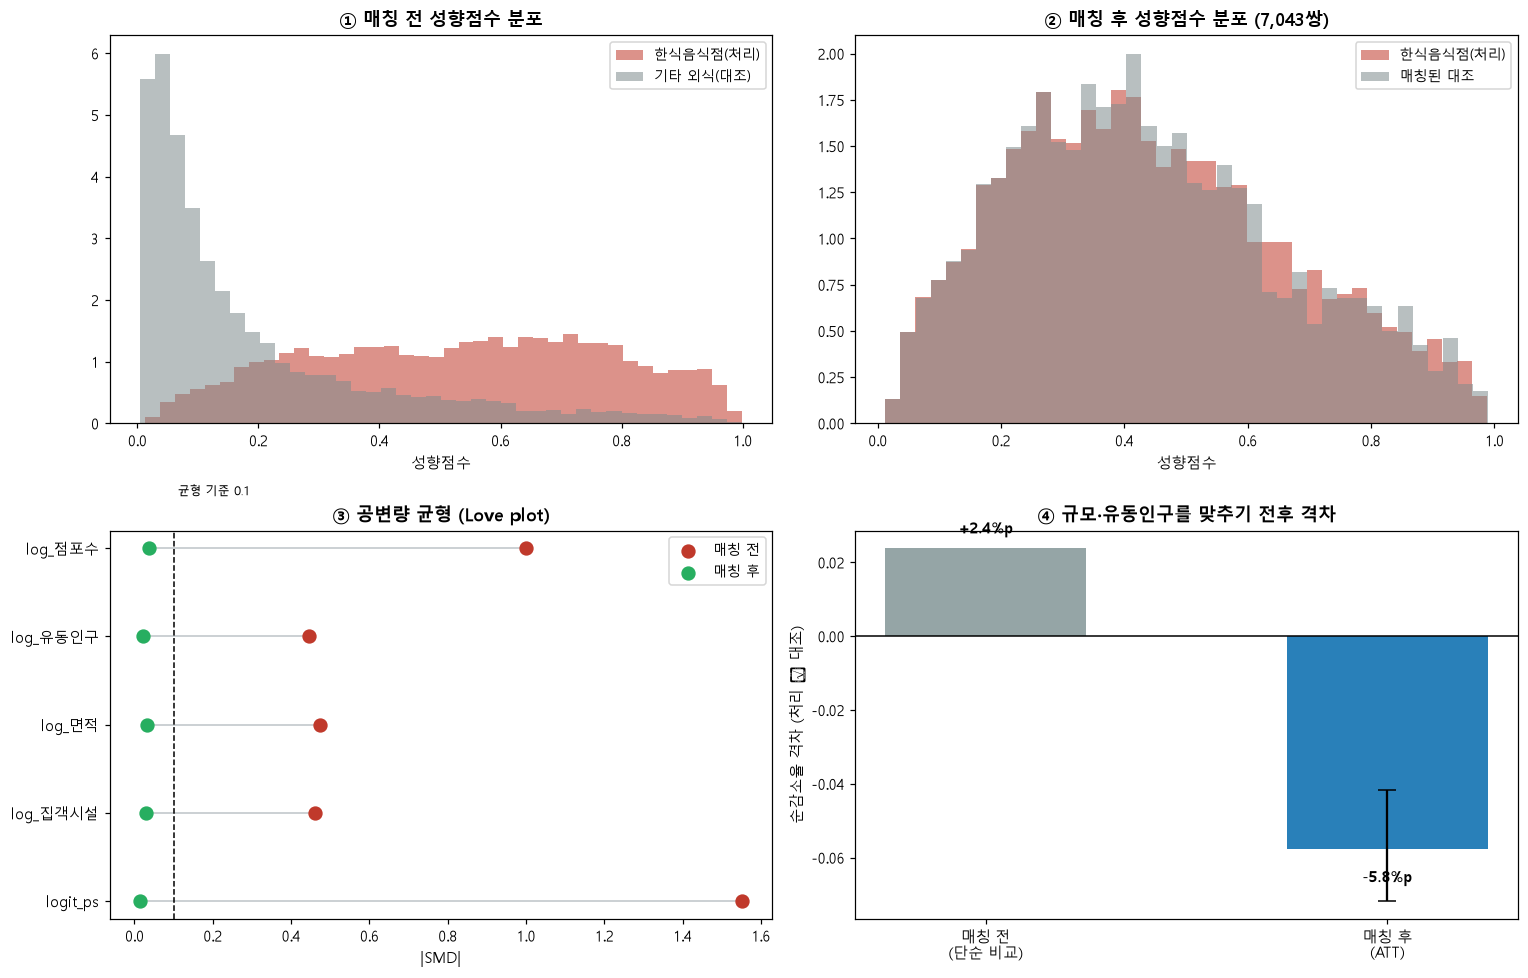

In [11]:
fig, ax = plt.subplots(2, 2, figsize=(14, 9))

for lab, sub_, col in [(f"{TREAT}(처리)", gm[gm["처리"]==1], "#c0392b"),
                       ("기타 외식(대조)", gm[gm["처리"]==0], "#7f8c8d")]:
    ax[0,0].hist(sub_["ps"], bins=40, alpha=.55, density=True, label=lab, color=col)
ax[0,0].set_title("① 매칭 전 성향점수 분포", weight="bold")
ax[0,0].set_xlabel("성향점수"); ax[0,0].legend(fontsize=9)

ax[0,1].hist(gm.loc[t_idx, "ps"], bins=40, alpha=.55, density=True, label=f"{TREAT}(처리)", color="#c0392b")
ax[0,1].hist(gm.loc[c_idx, "ps"], bins=40, alpha=.55, density=True, label="매칭된 대조", color="#7f8c8d")
ax[0,1].set_title(f"② 매칭 후 성향점수 분포 ({len(mp):,}쌍)", weight="bold")
ax[0,1].set_xlabel("성향점수"); ax[0,1].legend(fontsize=9)

lp = bal.iloc[::-1]
ypos = np.arange(len(lp))
ax[1,0].scatter(lp["매칭전_SMD"].abs(), ypos, s=70, c="#c0392b", label="매칭 전")
ax[1,0].scatter(lp["매칭후_SMD"].abs(), ypos, s=70, c="#27ae60", label="매칭 후")
for i, (a_, b_) in enumerate(zip(lp["매칭전_SMD"].abs(), lp["매칭후_SMD"].abs())):
    ax[1,0].plot([b_, a_], [i, i], c="#bdc3c7", lw=1, zorder=0)
ax[1,0].axvline(0.1, ls="--", c="k", lw=1)
ax[1,0].text(0.1, len(lp)-0.4, " 균형 기준 0.1", fontsize=8)
ax[1,0].set_yticks(ypos); ax[1,0].set_yticklabels(lp["공변량"])
ax[1,0].set_xlabel("|SMD|"); ax[1,0].set_title("③ 공변량 균형 (Love plot)", weight="bold")
ax[1,0].legend(fontsize=9)

labels = ["매칭 전\n(단순 비교)", "매칭 후\n(ATT)"]
vals = [gap_before, att]
bars = ax[1,1].bar(labels, vals, color=["#95a5a6", "#c0392b" if att > 0 else "#2980b9"], width=.5)
ax[1,1].errorbar(1, att, yerr=[[att-ci[0]], [ci[1]-att]], fmt="none", ecolor="k", capsize=6, lw=1.5)
ax[1,1].axhline(0, c="k", lw=1)
for bb, v in zip(bars, vals):
    ax[1,1].text(bb.get_x()+bb.get_width()/2, v + (0.004 if v > 0 else -0.009),
                 f"{v:+.1%}p", ha="center", weight="bold")
ax[1,1].set_ylabel("순감소율 격차 (처리 − 대조)")
ax[1,1].set_title("④ 규모·유동인구를 맞추기 전후 격차", weight="bold")

plt.tight_layout()
plt.savefig(FIG / "step6_psm.png", dpi=130)
plt.show()

## 6-9. 저장 및 H2 판정

In [12]:
matched = pd.concat([
    gm.loc[t_idx].assign(pair_id=np.arange(len(mp)), 역할="처리"),
    gm.loc[c_idx].assign(pair_id=np.arange(len(mp)), 역할="대조"),
]).sort_values(["pair_id", "역할"])

matched.to_pickle(PROC / "06_matched.pkl")
print(f"[저장] 06_matched.pkl  {matched.shape}   ← STEP 7 입력")
print(f"[저장] outputs/h2_balance_after.csv, h2_att.csv, figures/step6_psm.png\n")

print("── H2 판정 ─────────────────────────────")
print(f"H2 예측 : 규모·유동인구를 맞추면 {TREAT}과 타 업종의 순감소 격차가 줄어든다")
print(f"관측    : {gap_before:+.1%}p  →  {att:+.1%}p   (|격차| {abs(gap_before):.1%}p → {abs(att):.1%}p)")
if att * gap_before < 0:
    verdict = ("부분 지지(주의) — 격차가 줄어든 게 아니라 부호가 역전. "
               "단순 격차는 규모 교란의 산물이었고, 조건을 맞추면 처리군 위험이 오히려 낮음")
elif abs(att) < abs(gap_before):
    verdict = "지지 — 격차가 같은 방향으로 축소"
else:
    verdict = "기각 — 조건을 맞춰도 격차가 유지/확대"
print(f"판정    : {verdict}")
print()
print("보고 시 함께 적을 것")
print(f"  · 처리군 매칭률 {len(mp)/n_treat:.1%} — ATT 는 비교 가능한 구간에 한정된 효과")
print(f"  · 처리군 선택 부트스트랩 1위 비율 78.3% (STEP 5) — '상위권 업종의 효과'로 범위 설정")

[저장] 06_matched.pkl  (14086, 42)   ← STEP 7 입력
[저장] outputs/h2_balance_after.csv, h2_att.csv, figures/step6_psm.png

── H2 판정 ─────────────────────────────
H2 예측 : 규모·유동인구를 맞추면 한식음식점과 타 업종의 순감소 격차가 줄어든다
관측    : +2.4%p  →  -5.8%p   (|격차| 2.4%p → 5.8%p)
판정    : 부분 지지(주의) — 격차가 줄어든 게 아니라 부호가 역전. 단순 격차는 규모 교란의 산물이었고, 조건을 맞추면 처리군 위험이 오히려 낮음

보고 시 함께 적을 것
  · 처리군 매칭률 70.7% — ATT 는 비교 가능한 구간에 한정된 효과
  · 처리군 선택 부트스트랩 1위 비율 78.3% (STEP 5) — '상위권 업종의 효과'로 범위 설정


---

## STEP 7 에서 할 일 (보조질문 2 · 설명)

- 매칭 표본(`06_matched.pkl`) 위에서 로지스틱 회귀 → **이중강건 추정**
- 자치구 고정효과 투입
- 매출·점포밀도·프랜차이즈 비율 등 보조질문 2 변수의 계수·부호·유의성
- 프랜차이즈 비율은 STEP 4 에서 비단조(Q2 정점)로 확인됐으므로 선형 항만으로는 부족
